<a href="https://colab.research.google.com/github/MaabAllam/Emergency-Department-Analytics-Clinical-Operational-Financial-Performance-2025/blob/main/Health_care_data_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np


In [ ]:
df= pd.read_csv('/content/emergency_department_dataset.csv')

In [ ]:
df

,,encounter_id,arrival_datetime,triage_datetime,discharge_datetime,hospital_name,region_type,shift,age,age_group,...,boarding_time_minutes,length_of_stay_minutes,labs_ordered,medications_administered,estimated_charge_usd,readmit_72h_flag,hour_of_arrival,day_of_week,month,is_weekend
0,P000001,E0000001,01/01/2025 0:06,01/01/2025 0:42,01/01/2025 2:40,Central General,Urban,Day,44,40-64,...,0,175,3,2,3835.92,Yes,0,Wednesday,2025-01,False
1,P000002,E0000002,01/01/2025 0:16,01/01/2025 1:33,01/01/2025 3:54,Metro Health,Urban,Day,35,18-39,...,0,240,6,4,8543.33,No,0,Wednesday,2025-01,False
2,P000003,E0000003,01/01/2025 0:28,01/01/2025 0:52,01/01/2025 2:59,St. Mary ED,Rural,Day,80,65+,...,153,178,3,3,6785.87,No,0,Wednesday,2025-01,False
3,P000004,E0000004,01/01/2025 1:11,01/01/2025 2:12,01/01/2025 2:41,St. Mary ED,Urban,Day,3,0-17,...,0,119,17,4,15293.95,No,1,Wednesday,2025-01,False
4,P000005,E0000005,01/01/2025 1:59,01/01/2025 2:12,01/01/2025 2:42,Riverside Medical,Urban,Day,44,40-64,...,67,55,8,1,6926.45,No,1,Wednesday,2025-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,P009996,E0009996,30/12/2025 18:53,30/12/2025 19:46,30/12/2025 20:55,Riverside Medical,Urban,Evening,35,18-39,...,0,128,7,2,7858.83,No,18,Tuesday,2025-12,False
9996,P009997,E0009997,30/12/2025 19:17,30/12/2025 19:55,30/12/2025 23:03,Riverside Medical,Urban,Night,35,18-39,...,0,235,11,5,7610.65,No,19,Tuesday,2025-12,False
9997,P009998,E0009998,30/12/2025 19:41,30/12/2025 19:56,30/12/2025 22:24,Riverside Medical,Suburban,Night,44,40-64,...,91,176,5,5,5658.04,No,19,Tuesday,2025-12,False
9998,P009999,E0009999,30/12/2025 20:08,30/12/2025 20:30,30/12/2025 21:34,Central General,Urban,Evening,35,18-39,...,0,87,1,0,2582.87,No,20,Tuesday,2025-12,False


In [ ]:
print("Rows:",df.shape[0])

Rows: 10000


In [ ]:
print("columns:",df.shape[1])

columns: 31


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0                             10000 non-null  object 
 1   encounter_id              10000 non-null  object 
 2   arrival_datetime          10000 non-null  object 
 3   triage_datetime           10000 non-null  object 
 4   discharge_datetime        10000 non-null  object 
 5   hospital_name             10000 non-null  object 
 6   region_type               10000 non-null  object 
 7   shift                     10000 non-null  object 
 8   age                       10000 non-null  int64  
 9   age_group                 10000 non-null  object 
 10  gender                    10000 non-null  object 
 11  chief_complaint           10000 non-null  object 
 12  triage_acuity             10000 non-null  object 
 13  arrival_mode              10000 non-null  object 
 14  payer_t

In [ ]:
df.isnull().sum()

,0
,0
encounter_id,0
arrival_datetime,0
triage_datetime,0
discharge_datetime,0
hospital_name,0
region_type,0
shift,0
age,0
age_group,0


In [ ]:
df.head()

,,encounter_id,arrival_datetime,triage_datetime,discharge_datetime,hospital_name,region_type,shift,age,age_group,...,boarding_time_minutes,length_of_stay_minutes,labs_ordered,medications_administered,estimated_charge_usd,readmit_72h_flag,hour_of_arrival,day_of_week,month,is_weekend
0,P000001,E0000001,01/01/2025 0:06,01/01/2025 0:42,01/01/2025 2:40,Central General,Urban,Day,44,40-64,...,0,175,3,2,3835.92,Yes,0,Wednesday,2025-01,False
1,P000002,E0000002,01/01/2025 0:16,01/01/2025 1:33,01/01/2025 3:54,Metro Health,Urban,Day,35,18-39,...,0,240,6,4,8543.33,No,0,Wednesday,2025-01,False
2,P000003,E0000003,01/01/2025 0:28,01/01/2025 0:52,01/01/2025 2:59,St. Mary ED,Rural,Day,80,65+,...,153,178,3,3,6785.87,No,0,Wednesday,2025-01,False
3,P000004,E0000004,01/01/2025 1:11,01/01/2025 2:12,01/01/2025 2:41,St. Mary ED,Urban,Day,3,0-17,...,0,119,17,4,15293.95,No,1,Wednesday,2025-01,False
4,P000005,E0000005,01/01/2025 1:59,01/01/2025 2:12,01/01/2025 2:42,Riverside Medical,Urban,Day,44,40-64,...,67,55,8,1,6926.45,No,1,Wednesday,2025-01,False


In [ ]:
date_columns = ['arrival_datetime',
  'triage_datetime',
  'discharge_datetime']
for col in date_columns:
  df[col]=pd.to_datetime(df[col],dayfirst=True)

In [ ]:
df[date_columns].dtypes

,0
arrival_datetime,datetime64[ns]
triage_datetime,datetime64[ns]
discharge_datetime,datetime64[ns]


In [ ]:
df['encounter_id'].duplicated().sum()

np.int64(0)

In [ ]:
df['encounter_id'].nunique()

10000

In [ ]:
categorical_columns = [
    'hospital_name',
    'region_type',
    'shift',
    'age_group',
    'gender',
    'chief_complaint',
    'triage_acuity',
    'arrival_mode',
    'payer_type',
    'disposition',
    'admitted',
    'icu_flag',
    'left_without_being_seen',
    'readmit_72h_flag'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())



hospital_name:
hospital_name
Central General       2828
Riverside Medical     2174
Metro Health          1830
Northside Hospital    1690
St. Mary ED           1478
Name: count, dtype: int64

region_type:
region_type
Urban       5563
Suburban    3011
Rural       1426
Name: count, dtype: int64

shift:
shift
Day        4654
Evening    3169
Night      2177
Name: count, dtype: int64

age_group:
age_group
18-39    3459
40-64    3032
65+      2033
0-17     1476
Name: count, dtype: int64

gender:
gender
Female    5194
Male      4707
Other       99
Name: count, dtype: int64

chief_complaint:
chief_complaint
Trauma                 1596
Chest Pain             1392
Abdominal Pain         1258
Shortness of Breath    1190
Fever                  1037
Back Pain               929
Headache                906
Stroke Symptoms         826
Laceration              589
Weakness                277
Name: count, dtype: int64

triage_acuity:
triage_acuity
3-Urgent           3951
4-Less Urgent      3046
5-Non-Urg

In [ ]:
df.describe ()

,arrival_datetime,triage_datetime,discharge_datetime,age,icu_flag,wait_time_minutes,service_time_minutes,boarding_time_minutes,length_of_stay_minutes,labs_ordered,medications_administered,estimated_charge_usd,hour_of_arrival
count,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-06-29 20:58:40.584000,2025-06-29 21:46:29.837999616,2025-06-29 23:28:21.198000128,42.154100,0.005900,47.820900,101.856000,22.560300,169.875200,6.541600,3.154800,7867.712574,11.559300
min,2025-01-01 00:06:00,2025-01-01 00:42:00,2025-01-01 02:40:00,3.000000,0.000000,5.000000,10.000000,0.000000,29.000000,0.000000,0.000000,500.000000,0.000000
25%,2025-03-31 15:55:45,2025-03-31 16:34:00,2025-03-31 18:08:00,35.000000,0.000000,32.000000,56.000000,0.000000,122.000000,3.000000,1.000000,4207.662500,5.000000
50%,2025-06-29 06:43:30,2025-06-29 07:33:00,2025-06-29 10:20:30,44.000000,0.000000,47.000000,96.000000,0.000000,165.000000,6.000000,3.000000,7810.170000,12.000000
75%,2025-09-27 08:41:30,2025-09-27 09:24:30,2025-09-27 12:42:00,44.000000,0.000000,62.000000,144.000000,0.000000,215.000000,9.000000,5.000000,9505.987500,18.000000
max,2025-12-30 21:32:00,2025-12-30 22:01:00,2025-12-30 23:12:00,80.000000,1.000000,125.000000,264.000000,385.000000,380.000000,23.000000,15.000000,26491.180000,23.000000
std,NaN,NaN,NaN,23.157214,0.076588,21.769079,56.068919,58.124652,61.435987,4.137968,2.276479,4533.170789,6.975984


In [ ]:
numeric_columns = [
      'age',
    'wait_time_minutes',
  'service_time_minutes',
   'boarding_time_minutes',
   'length_of_stay_minutes',
   'labs_ordered',
 'medications_administered',
  'estimated_charge_usd' ]
df[numeric_columns].describe().round(2)


,age,wait_time_minutes,service_time_minutes,boarding_time_minutes,length_of_stay_minutes,labs_ordered,medications_administered,estimated_charge_usd
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,42.15,47.82,101.86,22.56,169.88,6.54,3.15,7867.71
std,23.16,21.77,56.07,58.12,61.44,4.14,2.28,4533.17
min,3.00,5.00,10.00,0.00,29.00,0.00,0.00,500.00
25%,35.00,32.00,56.00,0.00,122.00,3.00,1.00,4207.66
50%,44.00,47.00,96.00,0.00,165.00,6.00,3.00,7810.17
75%,44.00,62.00,144.00,0.00,215.00,9.00,5.00,9505.99
max,80.00,125.00,264.00,385.00,380.00,23.00,15.00,26491.18


In [ ]:
df[numeric_columns].isnull().sum()

,0
age,0
wait_time_minutes,0
service_time_minutes,0
boarding_time_minutes,0
length_of_stay_minutes,0
labs_ordered,0
medications_administered,0
estimated_charge_usd,0


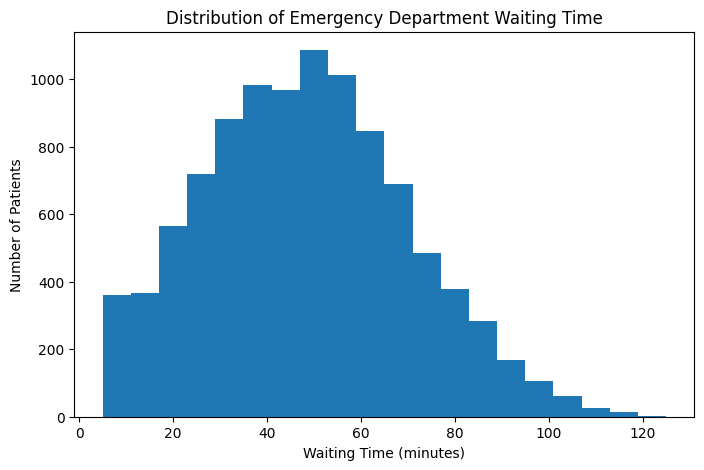

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['wait_time_minutes'], bins=20)
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Emergency Department Waiting Time')
plt.show()

Healthcare interpretation:
Most patients have relatively typical waiting times, while a smaller number experience considerably longer waits. This is not a highly distorted distribution.

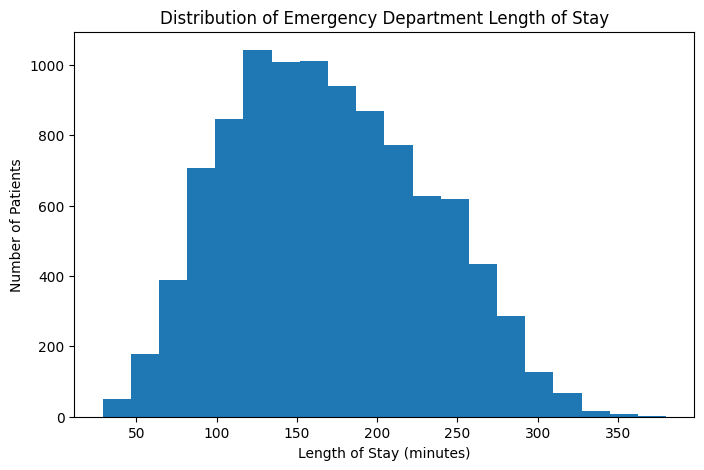

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['length_of_stay_minutes'], bins=20)
plt.xlabel('Length of Stay (minutes)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Emergency Department Length of Stay')
plt.show()

Length of stay is relatively balanced, with a slight right tail representing patients with longer ED stays.

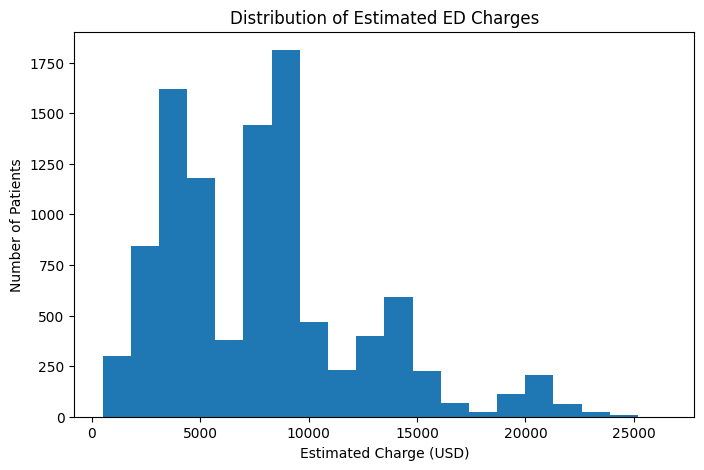

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['estimated_charge_usd'], bins=20)
plt.xlabel('Estimated Charge (USD)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Estimated ED Charges')
plt.show()

Most encounters have charges in the normal range, but a smaller number of encounters have substantially higher charges.

And this makes healthcare/business sense because higher-acuity encounters can involve more resources, investigations, medications, admission, etc.

In [ ]:
df[['wait_time_minutes',
    'length_of_stay_minutes',
        'estimated_charge_usd']].skew()

,0
wait_time_minutes,0.244719
length_of_stay_minutes,0.252238
estimated_charge_usd,0.985254


Are the extreme values legitimate clinical/operational encounters, and what characteristics do they have?

In [ ]:
outlier_columns = [
      'wait_time_minutes',
          'length_of_stay_minutes',
              'estimated_charge_usd'
              ]
for col in outlier_columns:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower_bound) |  (df[col] > upper_bound)]
print(f'\n{col}')
print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)
print('Number of Outliers:', len(outliers))



estimated_charge_usd
Q1: 4207.6625
Q3: 9505.9875
IQR: 5298.324999999999
Lower Bound: -3739.824999999998
Upper Bound: 17453.475
Number of Outliers: 436


here's the important healthcare-analytics point:

An outlier does not automatically mean an error.

A high charge could be completely legitimate—for example, a patient with high-acuity triage, ICU utilization, admission, extensive investigations, or more complex treatment.

So we should not delete these 436 records.

Instead, we're going to investigate them.

In [ ]:
high_charge = df[df['estimated_charge_usd'] > 17453.475]

high_charge[[
    'encounter_id',
             'hospital_name',
             'triage_acuity',
              'chief_complaint',
              'admitted',
              'icu_flag',
              'labs_ordered',
          'medications_administered',
          'estimated_charge_usd']].sort_values('estimated_charge_usd',ascending=False).head(10)

,encounter_id,hospital_name,triage_acuity,chief_complaint,admitted,icu_flag,labs_ordered,medications_administered,estimated_charge_usd
9574,E0009575,Northside Hospital,1-Resuscitation,Chest Pain,No,0,20,3,26491.18
9546,E0009547,St. Mary ED,1-Resuscitation,Stroke Symptoms,Yes,0,22,6,24967.76
9633,E0009634,Riverside Medical,1-Resuscitation,Fever,No,0,15,4,24748.26
4861,E0004862,Metro Health,1-Resuscitation,Chest Pain,No,1,17,5,24366.10
2901,E0002902,Metro Health,1-Resuscitation,Shortness of Breath,No,0,21,10,24295.99
2467,E0002468,Central General,1-Resuscitation,Abdominal Pain,No,0,13,10,24086.43
5665,E0005666,St. Mary ED,1-Resuscitation,Trauma,No,0,21,2,24026.48
3809,E0003810,Metro Health,1-Resuscitation,Abdominal Pain,No,0,17,5,23960.15
2970,E0002971,Central General,1-Resuscitation,Abdominal Pain,No,0,14,6,23785.51
7334,E0007335,Central General,1-Resuscitation,Abdominal Pain,No,1,13,10,23729.04


In [ ]:
high_charge['admitted'].value_counts()

,count
admitted,
No,279
Yes,157


In [ ]:
high_charge['triage_acuity'].value_counts()

,count
triage_acuity,
1-Resuscitation,415
2-Emergent,21


In [ ]:
high_charge['icu_flag'].value_counts()

,count
icu_flag,
0,418
1,18


In [ ]:
high_charge[['estimated_charge_usd',
             'labs_ordered',
             'medications_administered']].describe()

,estimated_charge_usd,labs_ordered,medications_administered
count,436.000000,436.000000,436.000000
mean,20575.509541,14.048165,5.892202
std,1256.644912,3.591813,2.441939
min,17464.350000,5.000000,0.000000
25%,19886.480000,12.000000,4.000000
50%,20490.110000,14.000000,6.000000
75%,21170.757500,16.000000,7.250000
max,26491.180000,23.000000,13.000000


In [ ]:
print("Overall average charge:",
      df['estimated_charge_usd'].mean())

print("High-charge average:",
      high_charge['estimated_charge_usd'].mean())

print("Overall average labs:",
      df['labs_ordered'].mean())

print("High-charge average labs:",
      high_charge['labs_ordered'].mean())

print("Overall average medications:",
      df['medications_administered'].mean())

print("High-charge average medications:",
      high_charge['medications_administered'].mean())

Overall average charge: 7867.712574000001
High-charge average: 20575.509541284406
Overall average labs: 6.5416
High-charge average labs: 14.04816513761468
Overall average medications: 3.1548
High-charge average medications: 5.8922018348623855


Outlier Analysis: Using the IQR method, 436 encounters (4.36%) were identified as high-charge outliers above $17,453.48. These encounters had an average estimated charge of $20,575.51 compared with $7,867.71 overall. They also showed higher average laboratory utilization (14.05 vs. 6.54) and medication utilization (5.89 vs. 3.15). Notably, 95.2% of high-charge encounters were classified as 1-Resuscitation, indicating a strong association between high clinical acuity, resource utilization, and estimated charges. These encounters were retained for analysis because extreme values in healthcare data may represent legitimate high-acuity cases rather than data errors.

In [ ]:
correlation_columns = [
    'wait_time_minutes',
    'service_time_minutes',
    'boarding_time_minutes',
    'length_of_stay_minutes',
    'labs_ordered',
    'medications_administered',
    'estimated_charge_usd'
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,wait_time_minutes,service_time_minutes,boarding_time_minutes,length_of_stay_minutes,labs_ordered,medications_administered,estimated_charge_usd
wait_time_minutes,1.00,0.02,-0.02,0.37,0.65,0.52,0.79
service_time_minutes,0.02,1.00,-0.00,0.92,0.02,-0.00,0.01
boarding_time_minutes,-0.02,-0.00,1.00,-0.01,-0.02,-0.02,0.21
length_of_stay_minutes,0.37,0.92,-0.01,1.00,0.25,0.18,0.29
labs_ordered,0.65,0.02,-0.02,0.25,1.00,0.50,0.78
medications_administered,0.52,-0.00,-0.02,0.18,0.50,1.00,0.60
estimated_charge_usd,0.79,0.01,0.21,0.29,0.78,0.60,1.00


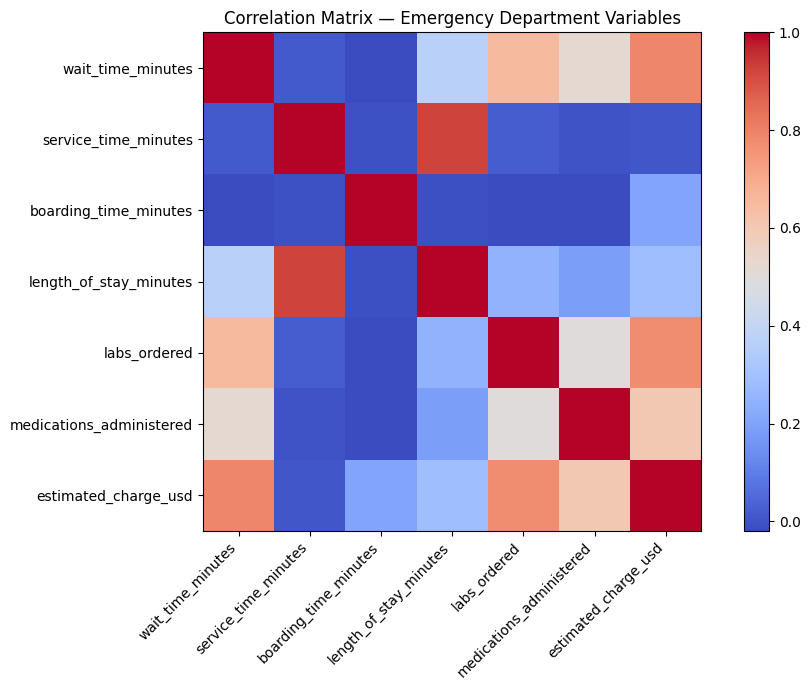

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title('Correlation Matrix — Emergency Department Variables')

plt.tight_layout()
plt.show()

In [ ]:
df['calculated_los'] = (
    df['wait_time_minutes']
    + df['service_time_minutes']
    + df['boarding_time_minutes']
)

df['los_difference'] = (
    df['length_of_stay_minutes']
    - df['calculated_los']
)

df['los_difference'].describe()

,los_difference
count,10000.000000
mean,-2.362000
std,58.851025
min,-361.000000
25%,8.000000
50%,18.000000
75%,25.000000
max,59.000000


In [ ]:
(df['los_difference'] == 0).sum()

np.int64(42)

Correlation analysis identified a very strong positive relationship between service time and length of stay (r = 0.92). However, validation of the underlying duration variables showed that length of stay does not simply equal the sum of waiting, service, and boarding time. Only 42 of 10,000 encounters matched this calculation exactly. Therefore, the correlation should be interpreted as an observed relationship rather than a direct mathematical dependency. Additional validation of duration definitions would be appropriate before using these variables for operational modeling.

Clinical & Operational **Relationships**

As patient acuity increases, do waiting time, LOS, resource utilization, and estimated charges also increase?**bold text**

Triage Acuity vs. Operational & Financial Metrics

In [ ]:
acuity_analysis = df.groupby('triage_acuity').agg(
    patient_count=('encounter_id', 'count'),
    avg_wait_time=('wait_time_minutes', 'mean'),
    median_wait_time=('wait_time_minutes', 'median'),
    avg_los=('length_of_stay_minutes', 'mean'),
    median_los=('length_of_stay_minutes', 'median'),
    avg_labs=('labs_ordered', 'mean'),
    avg_medications=('medications_administered', 'mean'),
    avg_charge=('estimated_charge_usd', 'mean')
).round(2)

acuity_analysis

,patient_count,avg_wait_time,median_wait_time,avg_los,median_los,avg_labs,avg_medications,avg_charge
triage_acuity,,,,,,,,
1-Resuscitation,415,89.91,90.0,212.35,209.0,14.13,5.89,20706.89
2-Emergent,1167,75.20,75.0,199.20,194.0,10.95,5.08,14250.30
3-Urgent,3951,54.93,55.0,176.73,172.0,8.08,3.99,8924.66
4-Less Urgent,3046,35.13,35.0,156.81,151.5,3.93,1.96,4694.93
5-Non-Urgent,1421,20.47,20.0,142.35,136.0,2.01,1.00,2738.62


Higher triage acuity was associated with longer waiting times, longer ED stays, greater laboratory and medication utilization, and higher estimated charges.

Acuity vs Waiting Time Distribution

In [ ]:
df.groupby('triage_acuity')['wait_time_minutes'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
triage_acuity,,,,,,,,
1-Resuscitation,415.0,89.91,12.35,51.0,81.0,90.0,99.0,125.0
2-Emergent,1167.0,75.20,11.83,37.0,67.0,75.0,84.0,116.0
3-Urgent,3951.0,54.93,11.88,11.0,47.0,55.0,63.0,95.0
4-Less Urgent,3046.0,35.13,11.80,5.0,27.0,35.0,43.0,77.0
5-Non-Urgent,1421.0,20.47,10.85,5.0,12.0,20.0,28.0,56.0


The dataset demonstrates a systematic increase in recorded waiting time as triage acuity increases. This pattern should be validated against the underlying workflow definitions and clinical timestamps before drawing conclusions about actual emergency-care performance.

Triage acuity showed a clear and consistent relationship with waiting time. Average and median waiting times increased progressively from 20.47 and 20 minutes for Non-Urgent encounters to 89.91 and 90 minutes for Resuscitation encounters. Similar mean and median values across all acuity groups indicate that the pattern is systematic rather than driven primarily by extreme observations. Because the dataset is synthetic, this relationship should be interpreted as a dataset-level pattern and validated against real ED workflow definitions before being used as a clinical performance benchmark.

Admission status

In [ ]:
admission_analysis = df.groupby('admitted').agg(
    patient_count=('encounter_id', 'count'),
    avg_wait_time=('wait_time_minutes', 'mean'),
    median_wait_time=('wait_time_minutes', 'median'),
    avg_los=('length_of_stay_minutes', 'mean'),
    median_los=('length_of_stay_minutes', 'median'),
    avg_labs=('labs_ordered', 'mean'),
    avg_medications=('medications_administered', 'mean'),
    avg_charge=('estimated_charge_usd', 'mean')
).round(2)

admission_analysis

,patient_count,avg_wait_time,median_wait_time,avg_los,median_los,avg_labs,avg_medications,avg_charge
admitted,,,,,,,,
No,8487,46.07,45.0,168.01,163.0,6.22,3.02,7435.93
Yes,1513,57.65,57.0,180.36,175.0,8.37,3.91,10289.76


Admitted ED encounters were associated with longer waiting times, longer lengths of stay, greater laboratory and medication utilization, and higher estimated charges compared with non-admitted encounters. This suggests that admission status is an important indicator of operational workload, resource utilization, and financial activity.